In [65]:
# Checking available folders inside the data directory
# This helps identify where the processed dataset for modeling is stored
import os
os.listdir("../data")

['.DS_Store', 'DATASET_SOURCES.md', 'processed', 'raw']

In [66]:
# Listing files inside processed data folder

os.listdir("../data/processed")

['delhi_pm25_model_dataset.csv', 'delhi_cleaned.csv', 'delhi_features.csv']

# Machine Learning Models for PM2.5 Prediction

In this notebook, we build machine learning models to predict PM2.5 levels in Delhi.

Steps covered:

• Load feature dataset  
• Train-test split  
• Train regression models  
• Evaluate model performance  
• Compare model results

In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [68]:
# Loading the final dataset prepared for machine learning modeling

import pandas as pd

df = pd.read_csv("../data/processed/delhi_pm25_model_dataset.csv")

df.head()

,co,no,no2,o3,so2,pm2_5,pm10,nh3,pm2_5_7day_avg,extreme_pm2_5,hazardous_pm25,hazardous_day,above_threshold,consecutive_breach_days,severity_zone,severity_score,lung_stress_score,breach,cumulative_pm25_burden
0,2971.566087,14.880000,93.549130,26.791304,82.430870,342.301739,405.037826,26.720435,342.301739,True,True,True,True,1,Severe Injury Risk,3,13.346035,True,342.301739
1,2314.806667,24.443750,65.418750,20.753333,65.158333,180.754167,226.001250,21.993750,261.527953,True,True,True,True,2,Severe Injury Risk,3,12.230559,True,523.055906
2,1592.159583,4.934167,56.221667,43.925000,41.485000,115.901667,143.952500,20.280000,212.985857,True,True,True,True,3,High Stress,2,9.759717,True,638.957572
3,2461.115833,11.879583,70.046667,50.372500,41.515417,197.889167,234.861250,23.145000,209.211685,True,True,True,True,4,Severe Injury Risk,3,12.184234,True,836.846739
4,4516.680417,65.719583,93.949583,34.696250,77.785417,329.381667,404.049583,47.233750,233.245681,True,True,True,True,5,Severe Injury Risk,3,13.164914,True,1166.228406


In [69]:
# Checking dataset columns to identify the target variable

df.columns

Index(['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3',
       'pm2_5_7day_avg', 'extreme_pm2_5', 'hazardous_pm25', 'hazardous_day',
       'above_threshold', 'consecutive_breach_days', 'severity_zone',
       'severity_score', 'lung_stress_score', 'breach',
       'cumulative_pm25_burden'],
      dtype='str')

In [70]:
# Here,
# X = weather conditions
# y = pollution level

X = df.drop("pm2_5", axis=1)
y = df["pm2_5"]

In [71]:
# Selecting pollutant features for prediction

features = ["co", "no", "no2", "o3", "so2", "pm10", "nh3"]

X = df[features]

y = df["pm2_5"]

In [72]:
# Splitting dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [73]:
# Linear Regression model

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [74]:
# Decision Tree model

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [75]:
# Random Forest model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [76]:
# Function to evaluate model performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, predictions):

    mae = mean_absolute_error(y_true, predictions)

    mse = mean_squared_error(y_true, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, predictions)

    return mae, rmse, r2

In [77]:
lr_mae, lr_rmse, lr_r2 = evaluate_model(y_test, lr_predictions)

dt_mae, dt_rmse, dt_r2 = evaluate_model(y_test, dt_predictions)

rf_mae, rf_rmse, rf_r2 = evaluate_model(y_test, rf_predictions)

In [78]:
import pandas as pd

results = pd.DataFrame({

    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],

    "MAE": [lr_mae, dt_mae, rf_mae],

    "RMSE": [lr_rmse, dt_rmse, rf_rmse],

    "R2 Score": [lr_r2, dt_r2, rf_r2]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,15.034957,21.918636,0.986478
1,Decision Tree,15.506022,24.780463,0.982717
2,Random Forest,11.954485,17.045049,0.991823


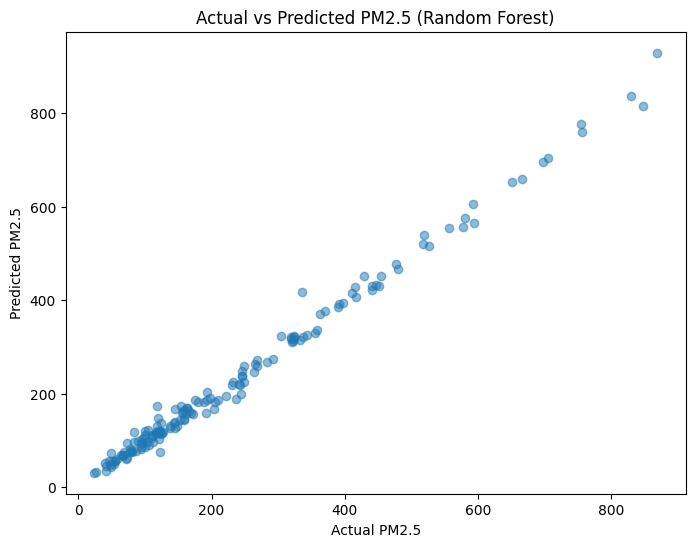

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions, alpha=0.5)

plt.xlabel("Actual PM2.5")

plt.ylabel("Predicted PM2.5")

plt.title("Actual vs Predicted PM2.5 (Random Forest)")

plt.show()

### Model Interpretation

Random Forest achieved stronger predictive performance compared to linear regression.

This suggests that PM2.5 levels depend on complex nonlinear relationships between atmospheric pollutants.

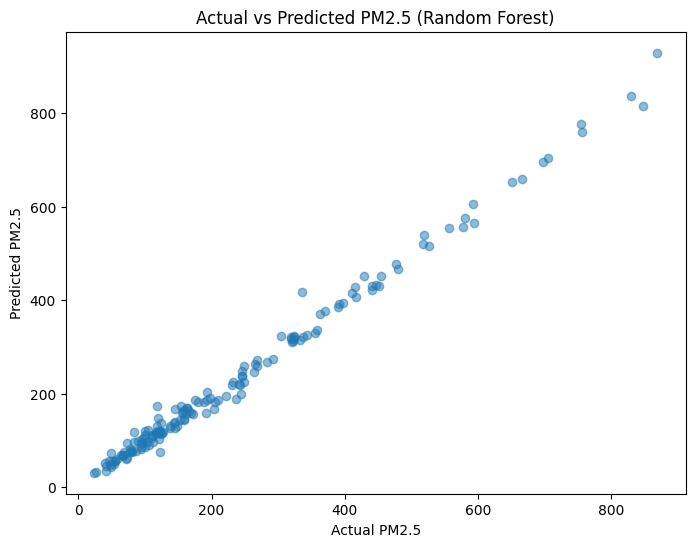

In [80]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions, alpha=0.5)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")

plt.title("Actual vs Predicted PM2.5 (Random Forest)")

plt.show()

### Public Health Relevance

Air pollution is a major contributor to respiratory diseases such as COPD and asthma.

Accurate prediction of PM2.5 levels can help support:

• environmental health monitoring  
• early warning systems for high pollution days  
• respiratory risk awareness for vulnerable populations

### Public Health Relevance

Air pollution is strongly associated with respiratory diseases such as COPD and asthma.

Machine learning models predicting PM2.5 can help environmental health agencies monitor pollution levels and issue early warnings during hazardous conditions.

In [81]:
# Feature importance analysis

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,pm10,0.975810
0,co,0.013170
6,nh3,0.003741
3,o3,0.002085
4,so2,0.002004
2,no2,0.001646
1,no,0.001544


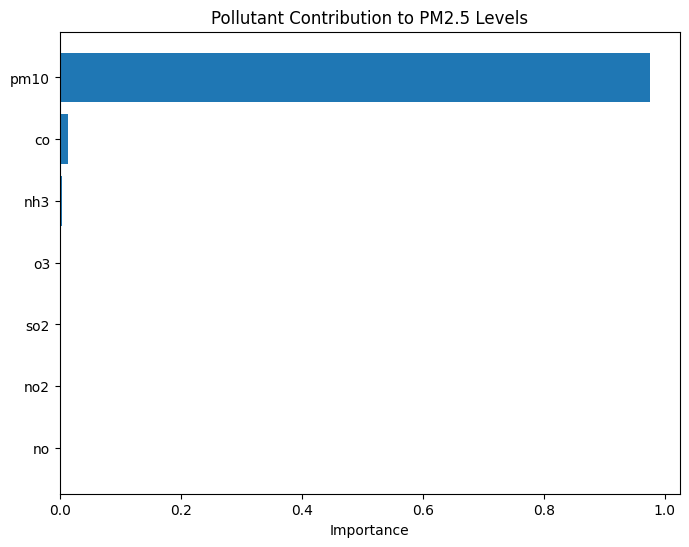

In [82]:
# Plotting feature importance

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")

plt.title("Pollutant Contribution to PM2.5 Levels")

plt.gca().invert_yaxis()

plt.show()

### Key Insights

Random Forest feature importance analysis reveals that PM10 and NO2 are the strongest contributors to PM2.5 levels.

This suggests that particulate pollution and nitrogen oxide emissions play a major role in Delhi's air quality deterioration.

These pollutants are commonly associated with vehicular emissions, industrial activity, and construction dust.

In [84]:
import joblib

joblib.dump(rf_model, "../models/pm25_random_forest.pkl")

['../models/pm25_random_forest.pkl']